In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

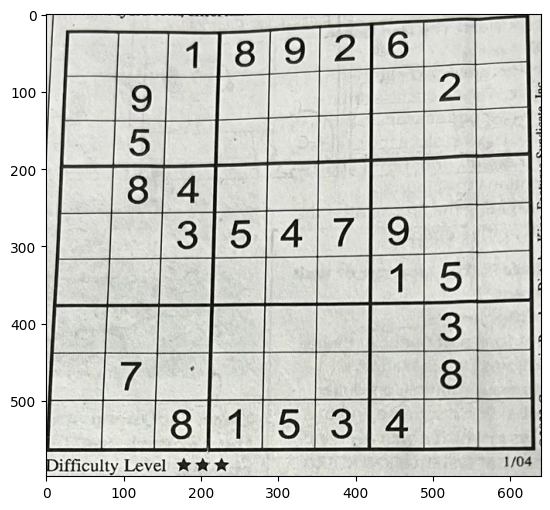

In [2]:
image = cv2.imread('sudoku.jpg')

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

# Why Is Canny Applied Before the Hough Transform?

The **Hough Transform** does not operate directly on the original image.

Instead, it requires an **edge image** as its input.

For this reason, the image is typically processed using an edge detection algorithm such as the **Canny Edge Detector** before applying the Hough Transform.

If the edges are not extracted accurately:

- Real lines may not be detected.
- False lines may be generated.
- The accuracy of the Hough Transform decreases significantly.

Therefore, the performance of the **Hough Transform** depends heavily on the quality of the **edge detection** stage.

In practice, the following pipeline is commonly used:

```text
Original Image
      │
      ▼
Gaussian Blur
      │
      ▼
Canny Edge Detection
      │
      ▼
Hough Transform
      │
      ▼
Detected Lines
```

This preprocessing pipeline helps reduce noise, preserve meaningful edges, and significantly improves the accuracy of line detection using the Hough Transform.

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blure = cv2.GaussianBlur(gray,(5,5),0)
edges = cv2.Canny(blure, 100, 200)

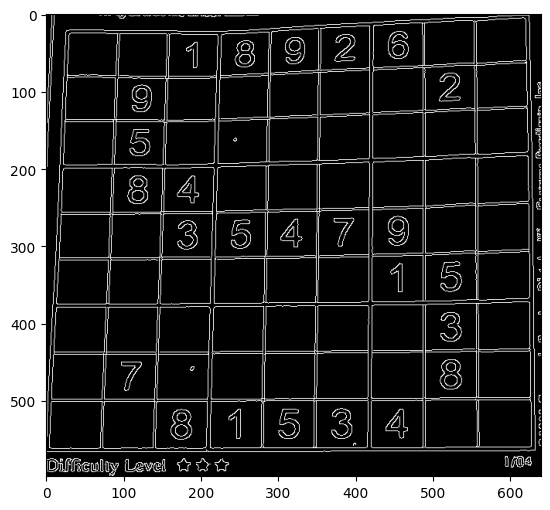

In [4]:
plt.figure(figsize=(12,6))
plt.imshow(edges, cmap='gray')
plt.show()

# hough line

# Parameters of `HoughLines`

The `cv2.HoughLines()` function detects lines in an **edge image** using the **Standard Hough Transform**.

Its basic syntax is:

```python
lines = cv2.HoughLines(image, rho, theta, threshold)
```

Each parameter plays an important role in the line detection process.

---

# 1. Input Image

The first parameter is the **edge image**.

In most applications, this is the output of the **Canny Edge Detector**.

```python
lines = cv2.HoughLines(edges, ...)
```

Providing a clean edge image significantly improves the accuracy of line detection.

---

# 2. Rho Resolution

The second parameter specifies the **distance resolution** of the accumulator in pixels.

For example:

```python
rho = 1
```

This means that the algorithm evaluates the distance parameter (\(\rho\)) with a resolution of **one pixel**.

- Smaller values provide higher detection accuracy.
- However, they also increase the computational cost.

---

# 3. Theta Resolution

The third parameter specifies the **angular resolution** of the accumulator.

A common choice is:

```python
np.pi / 180
```

which corresponds to an angular step of **1 degree**.

Using a smaller angular step:

- Improves the accuracy of line detection.
- Increases the processing time because more angles must be evaluated.

---

# 4. Threshold

The last parameter is one of the most important.

```python
threshold = 150
```

The **threshold** defines the minimum number of **votes** required for a line to be considered valid.

In other words:

> A line is detected only if it receives at least the specified number of votes in the Hough accumulator.

---

# Effect of the Threshold Value

## High Threshold

If the threshold is set to a high value:

- Only strong, long, and well-defined lines receive enough votes.
- Short or weak lines are discarded.
- The output contains fewer but more reliable detections.

---

## Low Threshold

If the threshold is set to a low value:

- Short and weak lines can also be detected.
- More line candidates appear in the output.
- The probability of detecting noise or false lines increases.

Therefore, selecting an appropriate threshold depends on the characteristics of the image, the expected line lengths, and the desired balance between **detection sensitivity** and **false positives**.

In [5]:
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

In [6]:
lines.shape

(40, 1, 2)

In [7]:
lines[0]

array([[487.,   0.]], dtype=float32)

# Converting $$(\rho, \theta)$$ to Drawable Line Endpoints

The `cv2.HoughLines()` function does not directly return the endpoints of a detected line.

Instead, it returns the line in its **polar representation**:

$$(\rho,\ \theta)$$


where:

- `ρ` is the **perpendicular distance** from the origin to the line.
- `θ` is the **angle of the line's normal** with respect to the x-axis.

However, the OpenCV function `cv2.line()` requires **two endpoints** to draw a line:

```text
(x1, y1)

(x2, y2)
```

Therefore, the values of **ρ** and **θ** must first be converted into two points lying on the detected line.





This conversion is performed using **trigonometric relationships**, specifically the **sine** and **cosine** functions.

A point on the line can be computed as:

$$x_0 = \rho \cos\theta$$

$$y_0 = \rho \sin\theta$$

Then, two distant endpoints are generated by extending the line in both directions:

```python
a = np.cos(theta)
b = np.sin(theta)

x0 = a * rho
y0 = b * rho

x1 = int(x0 + 1000 * (-b))
y1 = int(y0 + 1000 * ( a))

x2 = int(x0 - 1000 * (-b))
y2 = int(y0 - 1000 * ( a))
```

These two endpoints are then passed to `cv2.line()` to draw the detected line across the image.

In [8]:
image_line1 = image.copy()

for line in lines:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(image_line1, (x1, y1), (x2, y2), (0, 0, 255), 2)

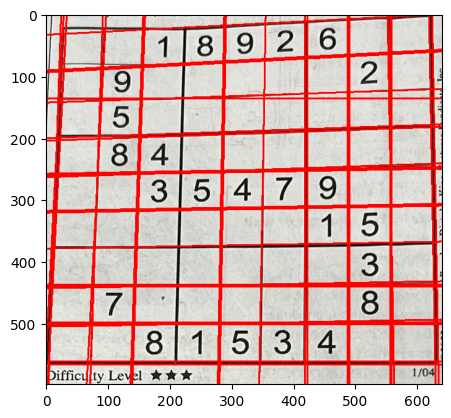

In [9]:
plt.imshow(cv2.cvtColor(image_line1, cv2.COLOR_BGR2RGB))
plt.show()

# Probabilistic Hough Transform

The second line detection method available in OpenCV is the **Probabilistic Hough Transform**, which is implemented using:

```python
cv2.HoughLinesP()
```

Unlike `cv2.HoughLines()`, this method does **not** return the line in polar coordinates \((\rho, \theta)\). Instead, it directly returns the **endpoints of each detected line segment**.

Each detected line is represented as:

```python
[x1, y1, x2, y2]
```

Since the line endpoints are already available, there is **no need to perform trigonometric calculations** to convert \((\rho, \theta)\) into drawable points. The returned coordinates can be passed directly to `cv2.line()`.

---

# Parameters of `HoughLinesP`

```python
cv2.HoughLinesP(
    edges,
    rho,
    theta,
    threshold,
    minLineLength,
    maxLineGap
)
```

The parameters are:

- **`edges`**: The edge image, typically the output of the Canny edge detector.

- **`rho`**: The distance resolution of the Hough accumulator in pixels.
  
  For example:

  ```python
  rho = 1
  ```

  means that the Hough space is evaluated with a resolution of **one pixel**.

- **`theta`**: The angular resolution of the accumulator in radians.

  A common choice is:

  ```python
  theta = np.pi / 180
  ```

  which corresponds to an angular resolution of **1 degree**.

- **`threshold`**: The minimum number of votes required for a line segment to be considered valid.

  - **Low threshold** → More line segments are detected, but the number of false detections may increase.
  - **High threshold** → Only stronger and more reliable line segments are detected.

- **`minLineLength`**: The minimum length of a line segment.

  Line segments shorter than this value are discarded.

  For example:

  ```python
  minLineLength = 50
  ```

  ignores all detected line segments shorter than **50 pixels**.

- **`maxLineGap`**: The maximum allowed gap between two line segments for them to be considered part of the same line.

  If edge detection produces small breaks along a line, this parameter allows nearby segments to be connected.

  For example:

  ```python
  maxLineGap = 20
  ```

  means that two line segments separated by less than **20 pixels** will be merged into a single line.

In [10]:
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=60, minLineLength=100, maxLineGap=60)

In [11]:
lines[0]

array([[490, 565, 490,   7]], dtype=int32)

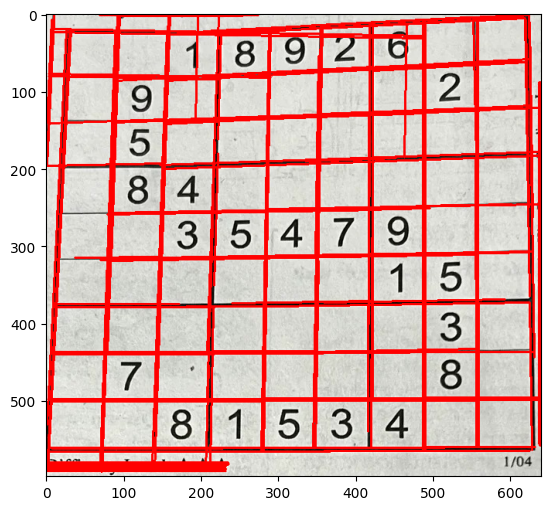

In [15]:
image_line2 = image.copy()

for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(image_line2, (x1, y1), (x2, y2), (0, 0, 255), 2)


plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(image_line2, cv2.COLOR_BGR2RGB))
plt.show()



# Effect of the Parameters

The quality of line detection using the **Probabilistic Hough Transform** depends heavily on the selected parameter values.

- **Decreasing `threshold`**
  - Detects more line segments.
  - Increases the likelihood of detecting noise and false lines.

- **Increasing `threshold`**
  - Retains only stronger and more reliable line segments.
  - May miss weak or short lines.

- **Increasing `minLineLength`**
  - Removes short line segments.
  - Helps suppress noise and insignificant detections.

- **Increasing `maxLineGap`**
  - Connects broken segments that belong to the same line.
  - If set too high, unrelated line segments may be incorrectly merged into a single line.

Choosing appropriate values for these parameters is essential for achieving a good balance between **detecting meaningful lines** and **avoiding false detections**.

---
---
---

# Drawing Lines in OpenCV

To draw a line in OpenCV, use the `cv2.line()` function:

```python
cv2.line(
    image,
    (x1, y1),
    (x2, y2),
    color,
    thickness
)
```

The function accepts the following parameters:

- **`image`**: The destination image on which the line will be drawn.
- **`(x1, y1)`**: The starting point of the line.
- **`(x2, y2)`**: The ending point of the line.
- **`color`**: The line color, specified as a BGR tuple (e.g., `(0, 0, 255)` for red).
- **`thickness`**: The thickness of the line, measured in pixels.

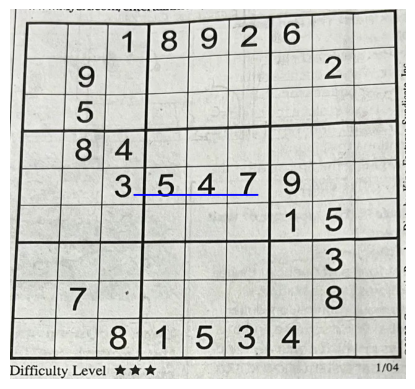

In [14]:
image2 = image.copy()

image2_line = cv2.line(image2,(200,300),(400,300),(255,0,0),2)


plt.imshow(cv2.cvtColor(image2_line, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()